# Trial-Based BunDLeNet Training on Two-Arm Bandit Data

This notebook showcases the **trial-based training regime** for BunDLeNet — an alternative to training on a single continuous time series.

### Why trial-based?

In the standard approach, `prep_data()` treats the full session as one long time series. This creates pairs that **cross trial boundaries** (e.g., a window spanning the jump from "reward/no reward" of one trial into "intertrial" of the next), which is biologically meaningless. It also forces a **temporal train/test split**, meaning the model is always tested on the "future" of the session.

### The three new utility functions

| Function | What it does |
|---|---|
| `segment_trials(X, B, b_labels_dict, trial_start_state)` | Splits the session into individual trials at boundary state transitions |
| `prep_data_trials(trial_segments, win)` | Runs `prep_data` independently per trial — no cross-trial windows ever |
| `trial_train_test_split(X_paired, B_1, trial_ids, test_ratio)` | Randomly assigns whole trials to train or test — no temporal ordering constraint |

`train_model()` and `BunDLeNet` are **completely unchanged**.


## 1. Imports & Data Loading

In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder

from ncmcm.data_loaders.bandit_task import BanditTaskNeuroPixelsDataset
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, project_into_latent_space
from ncmcm.bundlenet.utils import (
    prep_data,
    segment_trials,
    prep_data_trials,
    trial_train_test_split,
)
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
data_path = '../datasets/raw/twoArmBandit/JPAS_0023_20230922'

dataset = BanditTaskNeuroPixelsDataset(
    data_path=data_path,
    downsample_fs=30,
    downsample_method='gaussian',
    good_neurons_only=False,
    normalize_method='minmax_global',
    hgf_model='binary2',
    hgf_column='x_1_expected_mean',
    state_transitions=BanditTaskNeuroPixelsDataset.HOLD_TO_CHOOSING_TRANSITIONS
)

Dataset cached to: ../datasets/raw/twoArmBandit/JPAS_0023_20230922/BanditTaskNeuroPixelsDataset/fs30_gaussian_all_normminmax_global_1fbb0434.pkl
Loaded BanditTaskNeuroPixelsDataset from ../datasets/raw/twoArmBandit/JPAS_0023_20230922
Neuronal data shape: (575, 38794), Behavioral data shape: (1, 38794), Sampling frequency: 29.999289864765036 Hz
Behavioral labels: {0: 'intertrial', 1: 'reward', 2: 'no reward', 3: 'hold --> choosing left', 4: 'hold --> choosing right'}


In [7]:
X = dataset.x.toarray().T          # (T, N)  — time × neurons
B = dataset.b.toarray().flatten()  # (T,)    — integer behavioral labels

print(f"Data shape: X={X.shape}, B={B.shape}")

Data shape: X=(38794, 575), B=(38794,)


In [8]:
label_encoder = LabelEncoder()
B_encoded = label_encoder.fit_transform(B)

print(f"Unique behavioral labels: {label_encoder.classes_}")
print(f"Shape of encoded labels: {B_encoded.shape}")

Unique behavioral labels: [0 1 2 3 4]
Shape of encoded labels: (38794,)


In [9]:
b_labels     = dataset.b_labels_dict                   # {int: str}
b_colors     = dataset.get_color_map_for_plotting()    # {state_name: hex}
b_colors_rgb = dataset.get_rgb_colors_for_visualizer() # {state_name: (r,g,b)}

print(f"Labels: {b_labels}")
print(f"Color map: {b_colors}")

Labels: {0: 'intertrial', 1: 'reward', 2: 'no reward', 3: 'hold --> choosing left', 4: 'hold --> choosing right'}
Color map: {0: '#c7c7c7', 1: '#1ad367', 2: '#172E25', 3: '#e74c3c', 4: '#3498db'}


## 2. Segment Trials with `segment_trials()`

`segment_trials()` scans the behavioral label array for transitions **into** the `trial_start_state`. Each such transition marks the beginning of a new trial. Any data before the first complete trial is discarded.

```
B:  [intertrial intertrial hold choosing_left reward intertrial intertrial hold ...]
                ^─── trial 0 ──────────────────────^     ^─── trial 1 ───...
```

The function returns a list of `(X_trial, B_trial)` tuples — one per trial.


In [10]:
WIN = 30   # window size — used throughout this notebook

trial_segments = segment_trials(
    X, B_encoded, b_labels,
    trial_start_state='intertrial',
)

print(f"Trials found   : {len(trial_segments)}")
print(f"Neuronal part of first trial: {trial_segments[0][0].shape} (steps × neurons)")
print(f"Behavioral part of first trial: {trial_segments[0][1].shape} (steps,)")

print(f"First trial neuronal data: {trial_segments[0][0].shape}")

Trials found   : 237
Neuronal part of first trial: (91, 575) (steps × neurons)
Behavioral part of first trial: (91,) (steps,)
First trial neuronal data: (91, 575)


In [11]:
n_trials = len(trial_segments)
trial_lengths = [len(b_t) for _, b_t in trial_segments]

In [12]:
print(f"Trials found   : {n_trials}")
print(f"Length (steps) : min={min(trial_lengths)},  "
      f"max={max(trial_lengths)},  "
      f"mean={np.mean(trial_lengths):.1f},  "
      f"median={np.median(trial_lengths):.0f}")
print(f"Trials ≤ win ({WIN}): "
      f"{sum(l <= WIN for l in trial_lengths)}  (too short → skipped by prep_data_trials)")

Trials found   : 237
Length (steps) : min=85,  max=437,  mean=163.7,  median=135
Trials ≤ win (30): 0  (too short → skipped by prep_data_trials)


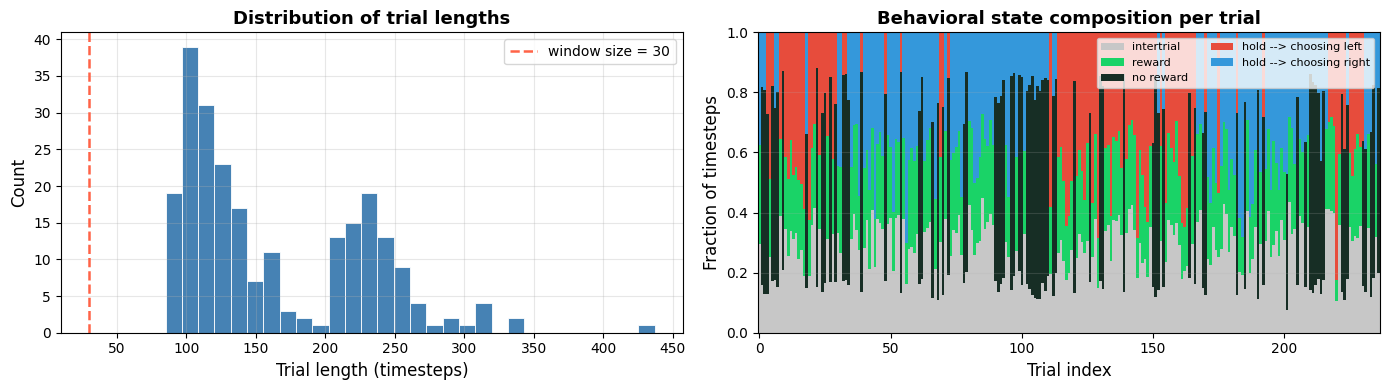

In [13]:
# ── Trial-length histogram + state composition ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram of trial lengths
ax = axes[0]
ax.hist(trial_lengths, bins=30, color='steelblue', edgecolor='white', linewidth=0.6)
ax.axvline(WIN, color='tomato', linestyle='--', linewidth=1.8,
           label=f'window size = {WIN}')
ax.set_xlabel('Trial length (timesteps)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of trial lengths', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: stacked bar of state composition per trial
ax = axes[1]
state_ids   = sorted(b_labels.keys())
state_names = [b_labels[k] for k in state_ids]
color_list  = [b_colors.get(k, '#aaaaaa') for k in state_ids]
# B_encoded uses LabelEncoder IDs (0,1,2,...) — map original IDs to encoded IDs
encoded_ids = label_encoder.transform(state_ids)

bottoms = np.zeros(n_trials)
for enc_id, s_name, col in zip(encoded_ids, state_names, color_list):
    fracs = np.array([(b_t == enc_id).mean() for _, b_t in trial_segments])
    ax.bar(range(n_trials), fracs, bottom=bottoms, color=col,
           label=s_name, width=1.0)
    bottoms += fracs

ax.set_xlabel('Trial index', fontsize=12)
ax.set_ylabel('Fraction of timesteps', fontsize=12)
ax.set_title('Behavioral state composition per trial', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.set_xlim(-0.5, n_trials - 0.5)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()


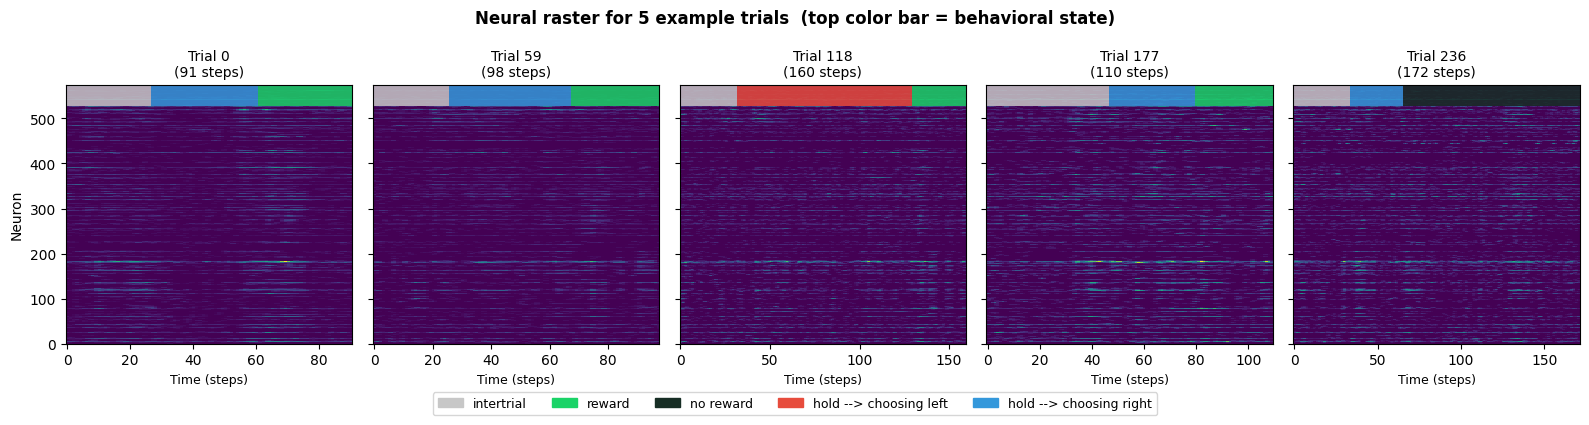

In [14]:
# ── Raster plot: 5 example trials side by side ───────────────────────────────
N_SHOW = 5
example_ids = np.linspace(0, n_trials - 1, N_SHOW, dtype=int)

fig, axes = plt.subplots(1, N_SHOW, figsize=(16, 4), sharey=True)
for ax, tid in zip(axes, example_ids):
    X_t, B_t = trial_segments[tid]
    ax.imshow(X_t.T, aspect='auto', cmap='viridis',
              origin='lower', interpolation='none')

    # Color bar along the top: one span per timestep, colored by behavioral state
    bar_frac = 0.08
    for t, state_id in enumerate(B_t):
        col = b_colors.get(label_encoder.inverse_transform([int(state_id)])[0], '#888888')
        ax.axvspan(t - 0.5, t + 0.5,
                   ymin=1 - bar_frac, ymax=1.0,
                   color=col, alpha=0.85, linewidth=0)

    ax.set_title(f'Trial {tid}\n({len(B_t)} steps)', fontsize=10)
    ax.set_xlabel('Time (steps)', fontsize=9)

axes[0].set_ylabel('Neuron', fontsize=10)

patches = [mpatches.Patch(color=b_colors.get(k, '#888'), label=b_labels[k])
           for k in sorted(b_labels)]
fig.legend(handles=patches, loc='lower center', ncol=len(patches),
           fontsize=9, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Neural raster for 5 example trials  (top color bar = behavioral state)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Window Trials with `prep_data_trials()`

`prep_data_trials()` calls `prep_data(win)` independently on each trial. This guarantees that **no windowed pair ever spans a trial boundary**.

It also returns a `trial_ids` array that records which trial every pair came from — this is essential for the trial-level split in the next step.

### What does a cross-trial pair look like in the continuous approach?

In continuous `prep_data()`, windows slide over the whole session with no knowledge of trial boundaries. A window of length 50 that starts 10 steps before a trial boundary will contain 10 steps from the end of trial *k* and 40 steps from the start of trial *k+1*. The corresponding pair `(window_t, window_{t+1})` spans the boundary. `prep_data_trials()` eliminates all such pairs by construction.


In [15]:
X_trials, B_trials, trial_ids = prep_data_trials(trial_segments, win=WIN)

# Continuous baseline for comparison
X_cont, B_cont = prep_data(X, B_encoded, win=WIN)

print("─── prep_data_trials() output ───────────────────────────────────")
print(f"  X_trials  : {X_trials.shape}   (pairs, 2, win, neurons)")
print(f"  B_trials  : {B_trials.shape}      (pairs,)")
print(f"  trial_ids : {trial_ids.shape}      values in [{trial_ids.min()}, {trial_ids.max()}]")
print()
print("─── Comparison: continuous prep_data() vs trial-based ───────────")
print(f"  Continuous pairs   : {X_cont.shape[0]:>7,}")
print(f"  Trial-based pairs  : {X_trials.shape[0]:>7,}")
pairs_removed = X_cont.shape[0] - X_trials.shape[0]
print(f"  Cross-trial pairs  : {pairs_removed:>7,}  "
      f"({100 * pairs_removed / X_cont.shape[0]:.1f}% eliminated)")


─── prep_data_trials() output ───────────────────────────────────
  X_trials  : (38764, 2, 30, 575)   (pairs, 2, win, neurons)
  B_trials  : (38764,)      (pairs,)
  trial_ids : (38764,)      values in [0, 236]

─── Comparison: continuous prep_data() vs trial-based ───────────
  Continuous pairs   :  38,764
  Trial-based pairs  :  38,764
  Cross-trial pairs  :       0  (0.0% eliminated)


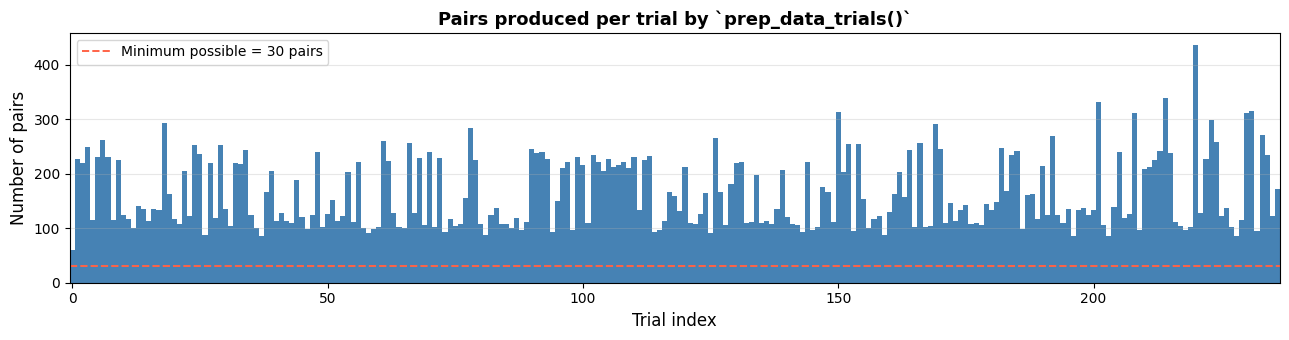

In [16]:
# ── Pairs per trial ───────────────────────────────────────────────────────────
pairs_per_trial = np.bincount(trial_ids, minlength=n_trials)

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.bar(range(n_trials), pairs_per_trial, color='steelblue',
       width=1.0, edgecolor='none')
ax.axhline(WIN, color='tomato', linestyle='--', linewidth=1.4,
           label=f'Minimum possible = {WIN} pairs')
ax.set_xlabel('Trial index', fontsize=12)
ax.set_ylabel('Number of pairs', fontsize=12)
ax.set_title('Pairs produced per trial by `prep_data_trials()`',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlim(-0.5, n_trials - 0.5)
plt.tight_layout()
plt.show()


## 4. Trial-Level Train/Test Split with `trial_train_test_split()`

`trial_train_test_split()` assigns **whole trials** to train or test at random. Every pair that comes from a given trial ends up entirely in train **or** entirely in test — there is zero leakage.

Contrast with the temporal KFold split used previously:

| | Temporal split | Trial-level split |
|---|---|---|
| Split boundary | Fixed time point | Random (per trial) |
| Leakage risk | No overlap in time | Guaranteed: whole trial goes to one set |
| Can shuffle? | No (order matters) | Yes — trials are i.i.d. |
| Test set resembles | End of session | Any random subset of trials |


In [17]:
TEST_RATIO   = 0.2
RANDOM_STATE = 42

(X_train, B_train), (X_test, B_test) = trial_train_test_split(
    X_trials, B_trials, trial_ids,
    test_ratio=TEST_RATIO,
    random_state=RANDOM_STATE,
)

# Recover per-trial assignment for plotting (mirror internal logic)
unique_trial_ids = np.unique(trial_ids)
rng = np.random.default_rng(RANDOM_STATE)
shuffled_ids = unique_trial_ids.copy()
rng.shuffle(shuffled_ids)
n_test_trials  = max(1, int(np.round(len(shuffled_ids) * TEST_RATIO)))
test_trial_set  = set(shuffled_ids[-n_test_trials:].tolist())
train_trial_set = set(shuffled_ids[:-n_test_trials].tolist())

# Sanity check: zero leakage
assert len(train_trial_set & test_trial_set) == 0, "Leakage detected!"

print(f"Total unique trials : {len(unique_trial_ids)}")
print(f"Train trials        : {len(train_trial_set)}  →  {X_train.shape[0]:,} pairs")
print(f"Test  trials        : {len(test_trial_set)}   →  {X_test.shape[0]:,} pairs")
print(f"Actual test ratio   : {X_test.shape[0] / X_trials.shape[0]:.1%}  (of pairs)")
print(f"Zero leakage check  : PASSED ✓")


Total unique trials : 237
Train trials        : 190  →  31,054 pairs
Test  trials        : 47   →  7,710 pairs
Actual test ratio   : 19.9%  (of pairs)
Zero leakage check  : PASSED ✓


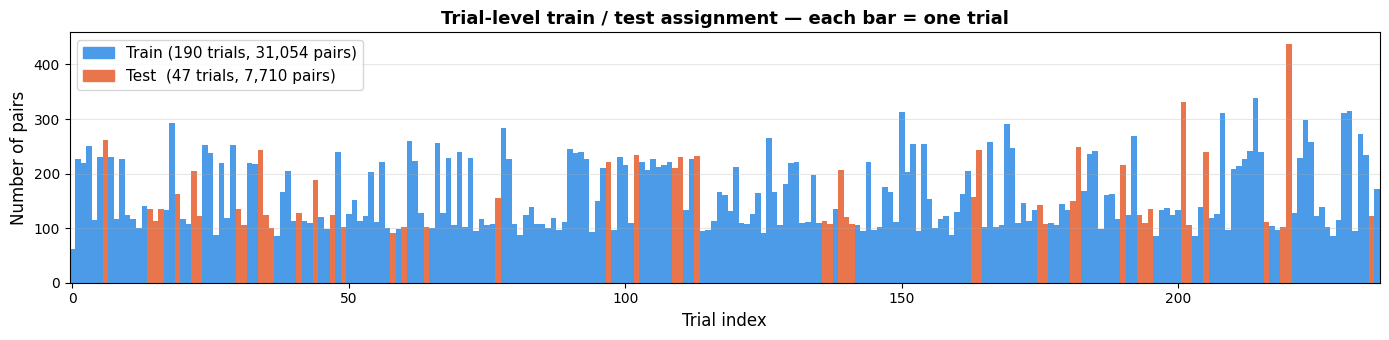

In [18]:
# ── Bar chart: pairs per trial, colored by split assignment ──────────────────
TRAIN_COL = '#4C9BE8'
TEST_COL  = '#E8754C'

fig, ax = plt.subplots(figsize=(14, 3.5))
for tid in range(n_trials):
    col = TEST_COL if tid in test_trial_set else TRAIN_COL
    ax.bar(tid, pairs_per_trial[tid], color=col, width=1.0, edgecolor='none')

train_patch = mpatches.Patch(color=TRAIN_COL,
    label=f'Train ({len(train_trial_set)} trials, {X_train.shape[0]:,} pairs)')
test_patch  = mpatches.Patch(color=TEST_COL,
    label=f'Test  ({len(test_trial_set)} trials, {X_test.shape[0]:,} pairs)')
ax.legend(handles=[train_patch, test_patch], fontsize=11)
ax.set_xlabel('Trial index', fontsize=12)
ax.set_ylabel('Number of pairs', fontsize=12)
ax.set_title('Trial-level train / test assignment — each bar = one trial',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlim(-0.5, n_trials - 0.5)
plt.tight_layout()
plt.show()


## 5. Train BunDLeNet on Trial-Based Data

The `train_model()` API is **completely unchanged** — only the data has changed. We pass `validation_data=(X_test, B_test)` to get per-epoch test loss for free.


In [19]:
N_EPOCHS   = 500
LATENT_DIM = 3
N_CLASSES  = len(b_labels)

model_trial = BunDLeNet(
    latent_dim=LATENT_DIM,
    num_behaviour=N_CLASSES,
    input_shape=X_train.shape,
)

print(f"BunDLeNet  latent_dim={LATENT_DIM}  n_classes={N_CLASSES}")
print(f"Train set  {X_train.shape[0]:,} pairs  shape={X_train.shape}")
print(f"Test  set  {X_test.shape[0]:,} pairs  shape={X_test.shape}")
print()

loss_array_trial, loss_array_test = train_model(
    X_train, B_train,
    model_trial,
    b_type='discrete',
    n_classes=N_CLASSES,
    gamma=0.75,
    learning_rate=5e-5,
    n_epochs=N_EPOCHS,
    validation_data=(X_test, B_test),
)

print()
print("─── Loss at key epochs ──────────────────────────────────────────")
header = f"{'Epoch':>6}  {'Train Markov':>13} {'Train Behav':>12} {'Train Total':>12} {'Test Total':>11}"
print(header)
print('─' * len(header))
for epoch in [0, N_EPOCHS // 4, N_EPOCHS // 2, 3 * N_EPOCHS // 4, N_EPOCHS - 1]:
    tr = loss_array_trial[epoch]
    te = loss_array_test[epoch]
    print(f"{epoch+1:>6}  {tr[0]:>13.4f} {tr[1]:>12.4f} {tr[2]:>12.4f} {te[2]:>11.4f}")


BunDLeNet  latent_dim=3  n_classes=5
Train set  31,054 pairs  shape=(31054, 2, 30, 575)
Test  set  7,710 pairs  shape=(7710, 2, 30, 575)



Loss [Markov, Behaviour, Total]: [0.007  0.0023 0.0093 0.     0.    ]: 100%|██████████| 500/500 [09:30<00:00,  1.14s/it]


─── Loss at key epochs ──────────────────────────────────────────
 Epoch   Train Markov  Train Behav  Train Total  Test Total
───────────────────────────────────────────────────────────
     1         0.1503       0.3502       0.5005      0.4811
   126         0.0128       0.0077       0.0205      0.5979
   251         0.0092       0.0044       0.0136      0.5912
   376         0.0077       0.0029       0.0107      0.6332
   500         0.0070       0.0023       0.0093      0.6220


## 6. Plot Training & Validation Loss

$$\mathcal{L} = \mathcal{L}_{\mathrm{Markov}} + \gamma \cdot \mathcal{L}_{\mathrm{Behavior}}$$

Solid = train, dashed = test. A growing gap between the two signals overfitting.


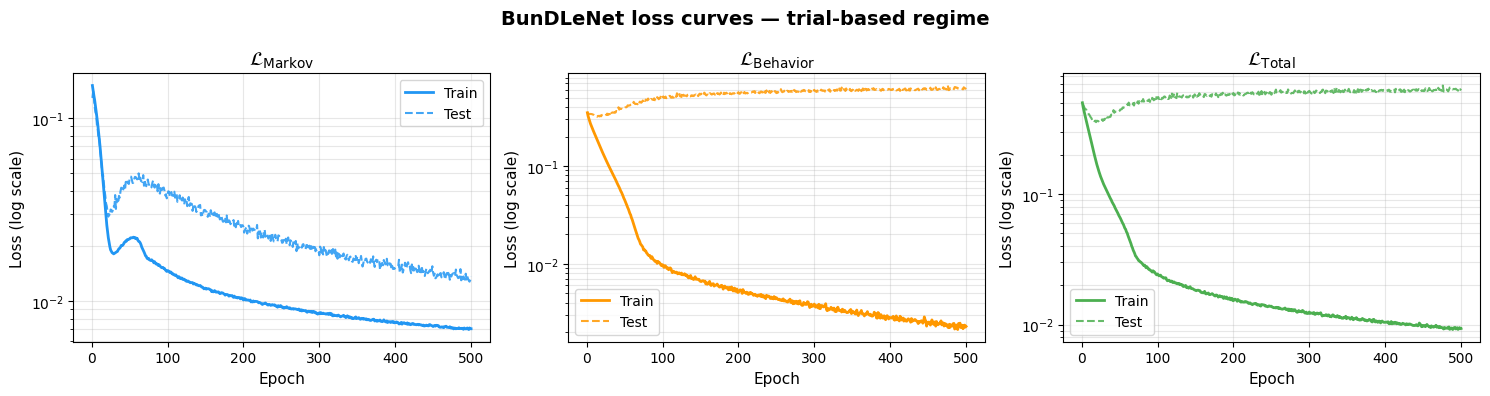


Final epoch loss:
  Markov      train=0.0070  test=0.0136  gap=+0.0066
  Behavior    train=0.0023  test=0.6083  gap=+0.6061
  Total       train=0.0093  test=0.6220  gap=+0.6126


In [25]:
loss_labels = [
    r"$\mathcal{L}_{\mathrm{Markov}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"$\mathcal{L}_{\mathrm{Total}}$",
]
palette = ['#2196F3', '#FF9800', '#4CAF50']
epochs  = np.arange(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for i, (ax, lbl, col) in enumerate(zip(axes, loss_labels, palette)):
    ax.semilogy(epochs, loss_array_trial[:, i], color=col,
                linewidth=2, label='Train')
    ax.semilogy(epochs, loss_array_test[:, i],  color=col,
                linewidth=1.5, linestyle='--', alpha=0.85, label='Test')
    ax.set_title(lbl, fontsize=14)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss (log scale)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, which='both')

fig.suptitle('BunDLeNet loss curves — trial-based regime',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Final train/test gap
print("\nFinal epoch loss:")
for i, lbl in enumerate(["Markov", "Behavior", "Total"]):
    gap = loss_array_test[-1, i] - loss_array_trial[-1, i]
    print(f"  {lbl:<10}  train={loss_array_trial[-1,i]:.4f}  "
          f"test={loss_array_test[-1,i]:.4f}  gap={gap:+.4f}")


## 7. Project & Visualize Latent Space

We project train and test pairs **separately** into the learned 3-D latent space and compare them visually.


In [26]:
print("Projecting train set into latent space...")
Y_train = project_into_latent_space(X_train, model_trial)

print("Projecting test  set into latent space...")
Y_test  = project_into_latent_space(X_test,  model_trial)

print(f"\nY_train : {Y_train.shape}")
print(f"Y_test  : {Y_test.shape}")


Projecting train set into latent space...
Projecting test  set into latent space...

Y_train : (31054, 3)
Y_test  : (7710, 3)


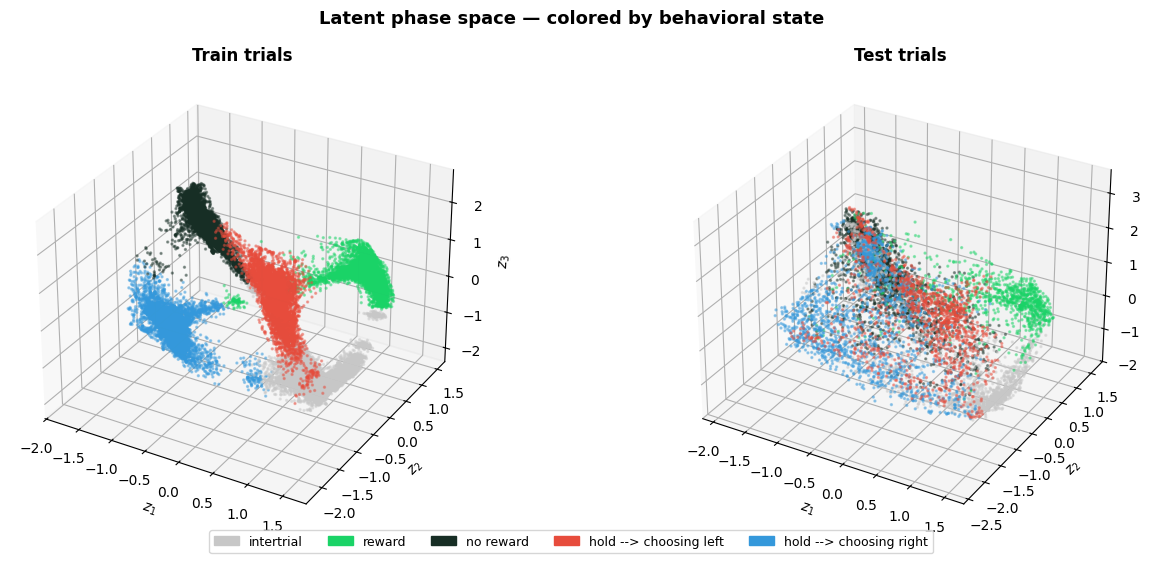

In [27]:
# ── 3D phase space: train vs test, colored by behavioral state ────────────────
fig = plt.figure(figsize=(14, 5.5))

for col_idx, (Y, B_vis, title) in enumerate([
    (Y_train, B_train, 'Train trials'),
    (Y_test,  B_test,  'Test trials'),
]):
    ax = fig.add_subplot(1, 2, col_idx + 1, projection='3d')
    for i, state_id in enumerate(sorted(b_labels.keys())):
        enc_id = label_encoder.transform([state_id])[0]
        mask = B_vis == enc_id
        if not mask.any():
            continue
        col = b_colors_rgb[i]
        ax.scatter(Y[mask, 0], Y[mask, 1], Y[mask, 2],
                   s=2, alpha=0.4, color=col, label=b_labels[state_id])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$'); ax.set_zlabel('$z_3$')

handles = [mpatches.Patch(color=b_colors_rgb[i], label=b_labels[k])
           for i, k in enumerate(sorted(b_labels))]
fig.legend(handles=handles, loc='lower center', ncol=len(handles),
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Latent phase space — colored by behavioral state',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


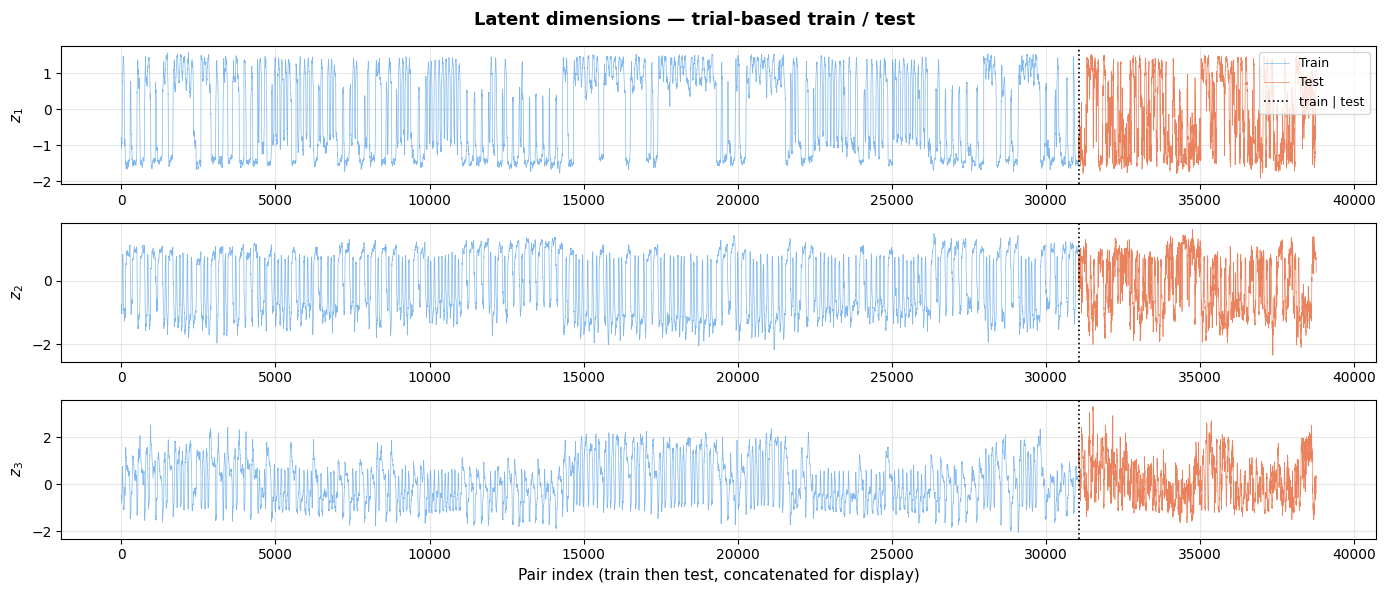

In [28]:
# ── Latent time-series — all 3 dimensions ────────────────────────────────────
fig, axes = plt.subplots(LATENT_DIM, 1, figsize=(14, 6), sharex=False)

for dim, ax in enumerate(axes):
    ax.plot(Y_train[:, dim], color=TRAIN_COL, lw=0.5, alpha=0.7, label='Train')
    offset = len(Y_train)
    ax.plot(np.arange(len(Y_test)) + offset, Y_test[:, dim],
            color=TEST_COL, lw=0.5, alpha=0.9, label='Test')
    ax.axvline(offset, color='black', linewidth=1.2, linestyle=':',
               label='train | test')
    ax.set_ylabel(f'$z_{dim+1}$', fontsize=11)
    ax.grid(True, alpha=0.3)
    if dim == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Pair index (train then test, concatenated for display)',
                    fontsize=11)
fig.suptitle('Latent dimensions — trial-based train / test',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


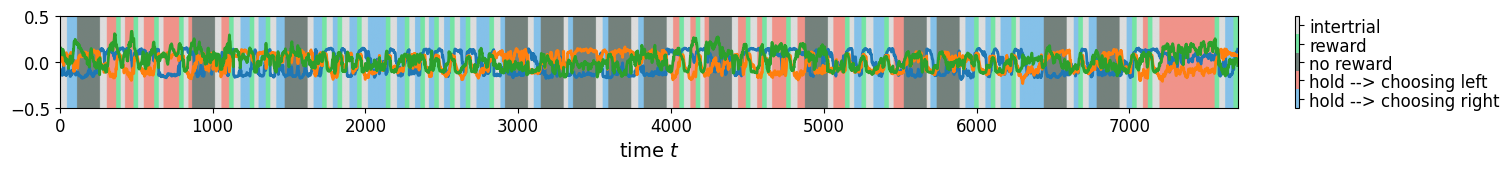

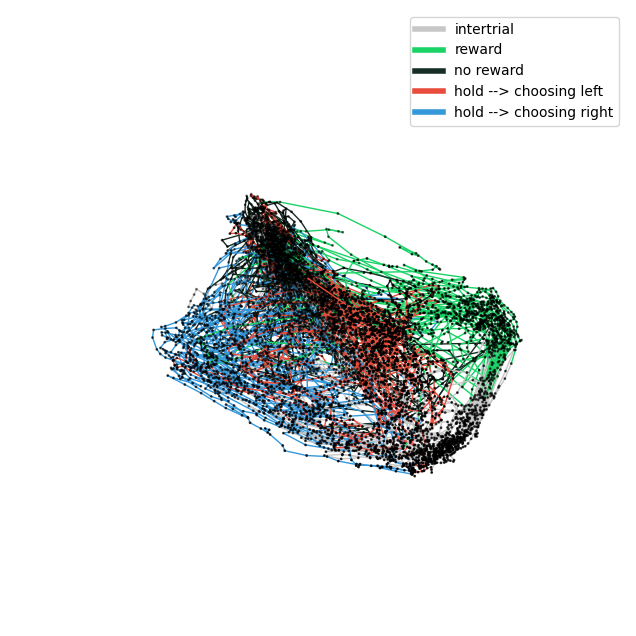

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [24]:
# ── LatentSpaceVisualiser on test data ────────────────────────────────────────
vis = LatentSpaceVisualiser(
    Y_test, B_test, b_labels,
    show_points=True,
    colors=b_colors_rgb,
)

vis.plot_latent_timeseries()
vis.plot_phase_space()
